# Gradient Boosting Model for Delinquency Prediction

Uses the **top 50 selected features** from the comprehensive feature selection pipeline.

- Train / Validation / Test split (60/20/20)
- `GradientBoostingClassifier` (scikit-learn)
- Handles class imbalance via `sample_weight`
- No feature scaling required (tree-based model)
- **Optuna** (TPE sampler) for hyperparameter search
- Records training time, scoring time, ROC-AUC, and Average Precision

In [12]:
import sys
import pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    precision_recall_curve, average_precision_score, roc_curve,
)
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from scripts.model_data import load_and_split, save_sorted_features

## 1. Load Data & Selected Features

In [13]:
# ── Configuration ────────────────────────────────────────────────
N_FEATURES = 100  # ← change this to use a different number of top-ranked features

# Write output/sorted_features.csv (columns ordered by rank) once
save_sorted_features()

# Load features and perform 60/20/20 stratified split
X_train, X_val, X_test, y_train, y_val, y_test, available_features, features_df = \
    load_and_split(n_features=N_FEATURES)

print(f'Features used:  {len(available_features)}')
print(f'Train:          {X_train.shape}  |  positives: {y_train.sum()} ({100*y_train.mean():.1f}%)')
print(f'Validation:     {X_val.shape}  |  positives: {y_val.sum()} ({100*y_val.mean():.1f}%)')
print(f'Test:           {X_test.shape}  |  positives: {y_test.sum()} ({100*y_test.mean():.1f}%)')

Saved sorted_features.csv  (182 ranked + 55 other columns)
Features  : 100 (top-100)
Samples   : 10317  |  DQ rate: 8.86%
Train     : 6190  (8.85% positive)
Val       : 2063  (8.87% positive)
Test      : 2064  (8.87% positive)
Features used:  100
Train:          (6190, 100)  |  positives: 548 (8.9%)
Validation:     (2063, 100)  |  positives: 183 (8.9%)
Test:           (2064, 100)  |  positives: 183 (8.9%)


## 2. Class Imbalance Weights

`GradientBoostingClassifier` does not have a `class_weight` parameter, so we pass per-sample weights directly to `fit()`.

In [14]:
n_neg = int(np.sum(y_train == 0))
n_pos = int(np.sum(y_train == 1))
scale_pos_weight = n_neg / n_pos
print(f'scale_pos_weight: {scale_pos_weight:.2f}  (neg={n_neg}, pos={n_pos})')

# Build per-sample weight array (minority class gets higher weight)
sample_weight_train = np.where(y_train == 1, scale_pos_weight, 1.0)

scale_pos_weight: 10.30  (neg=5642, pos=548)


## 3. Baseline Model

Quick sanity-check with default-ish parameters before tuning.

In [15]:
baseline = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=50,
    random_state=42,
    verbose=0,
)

print('Training baseline model…')
t0 = time.time()
baseline.fit(X_train, y_train, sample_weight=sample_weight_train)
t_baseline = time.time() - t0

baseline_val_auc = roc_auc_score(y_val, baseline.predict_proba(X_val)[:, 1])
print(f'Baseline trained in {t_baseline:.1f}s')
print(f'Baseline Val AUC : {baseline_val_auc:.4f}')

Training baseline model…
Baseline trained in 57.8s
Baseline Val AUC : 0.8024


## 4. Hyperparameter Tuning with Optuna

Search over the key knobs for `GradientBoostingClassifier`:

| Parameter | Controls |
|---|---|
| `max_depth` | Tree complexity |
| `learning_rate` | Shrinkage per tree |
| `subsample` | Stochastic gradient boosting fraction |
| `min_samples_leaf` | Minimum leaf size (regularisation) |
| `min_samples_split` | Minimum split size |
| `max_features` | Feature fraction per split |
| `n_iter_no_change` | Early stopping patience |

In [16]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 60  # increase for a more thorough search

def objective(trial):
    params = dict(
        n_estimators      = 1000,          # high; early stopping controls actual count
        max_depth         = trial.suggest_int('max_depth', 2, 6),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 10, 100),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 40),
        max_features      = trial.suggest_float('max_features', 0.3, 1.0),
        n_iter_no_change  = trial.suggest_int('n_iter_no_change', 10, 40),
        validation_fraction = 0.0,         # we supply our own val set via warm-start scoring
        tol               = 1e-4,
        random_state      = 42,
        verbose           = 0,
    )

    # sklearn GBM early-stopping requires validation_fraction > 0
    # Instead, combine train+val and use n_iter_no_change on the val score manually
    params['validation_fraction'] = 0.2   # held-out slice inside train

    model = GradientBoostingClassifier(**params)
    model.fit(X_train, y_train, sample_weight=sample_weight_train)

    val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    return val_auc

sampler = optuna.samplers.TPESampler(seed=42)
pruner  = optuna.pruners.MedianPruner(n_warmup_steps=10)
study   = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner)

print(f'Running Optuna search ({N_TRIALS} trials) …')
t_tune = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'Search finished in {time.time() - t_tune:.1f}s')
print(f'\nBest val AUC : {study.best_value:.4f}')
print(f'Best params  :')
for k, v in study.best_params.items():
    print(f'  {k:<25} {v}')

Running Optuna search (60 trials) …


  0%|          | 0/60 [00:00<?, ?it/s]

Search finished in 219.8s

Best val AUC : 0.7980
Best params  :
  max_depth                 4
  learning_rate             0.017526597163399212
  subsample                 0.5268115655921943
  min_samples_leaf          93
  min_samples_split         28
  max_features              0.49044809364125297
  n_iter_no_change          26


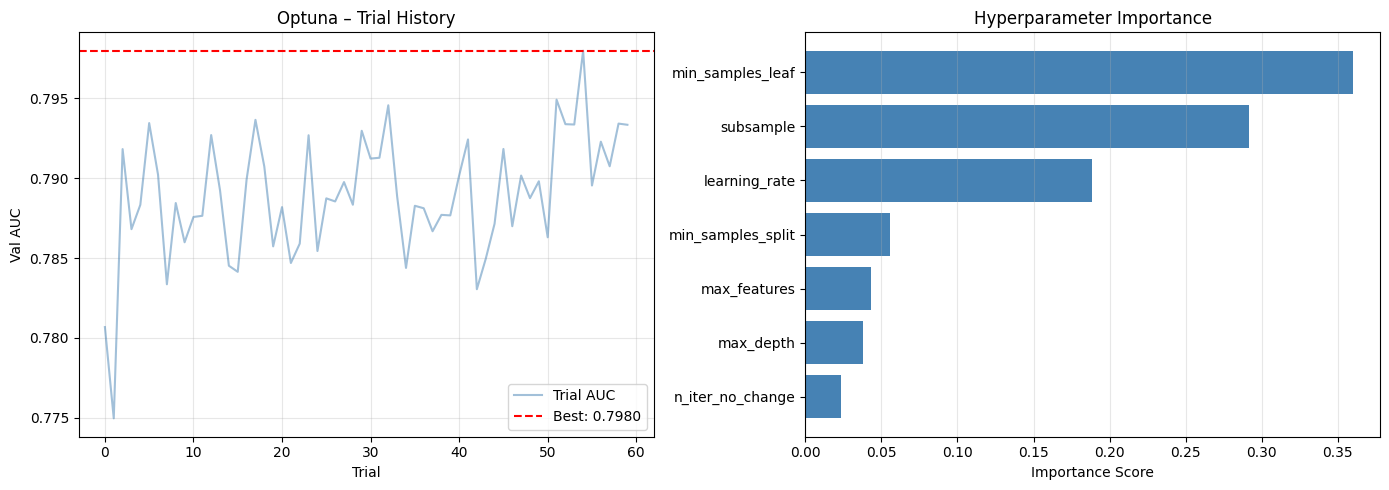

In [17]:
# ── Optuna visualisation ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial AUC history
trial_values = [t.value for t in study.trials if t.value is not None]
axes[0].plot(trial_values, alpha=0.5, color='steelblue', label='Trial AUC')
axes[0].axhline(study.best_value, color='red', linestyle='--',
                label=f'Best: {study.best_value:.4f}')
axes[0].set(title='Optuna – Trial History', xlabel='Trial', ylabel='Val AUC')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Parameter importance
importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys())[::-1], list(importances.values())[::-1], color='steelblue')
axes[1].set(title='Hyperparameter Importance', xlabel='Importance Score')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Train Final Model with Best Hyperparameters

In [18]:
best_params = dict(
    n_estimators        = 1000,
    validation_fraction = 0.2,
    tol                 = 1e-4,
    random_state        = 42,
    verbose             = 1,
    **study.best_params,
)

print(f'Training final Gradient Boosting with best params (top-{N_FEATURES} features)…')
t0 = time.time()
model = GradientBoostingClassifier(**best_params)
model.fit(X_train, y_train, sample_weight=sample_weight_train)
training_time = time.time() - t0

print(f'\nTraining completed in {training_time:.2f}s  ({training_time/60:.2f} min)')
print(f'Actual n_estimators used : {model.n_estimators_}')

Training final Gradient Boosting with best params (top-100 features)…
      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.3747           0.0095           16.82s
         2           1.3638           0.0086           16.29s
         3           1.3554           0.0109           14.94s
         4           1.3463           0.0100           15.89s
         5           1.3343           0.0070           15.58s
         6           1.3262           0.0088           15.72s
         7           1.3220           0.0130           15.98s
         8           1.3139           0.0084           15.45s
         9           1.3022           0.0051           15.97s
        10           1.2925           0.0063           15.92s
        20           1.2248           0.0063           16.37s
        30           1.1723           0.0047           16.26s
        40           1.1350           0.0034           16.15s
        50           1.0962          -0.0112           15.86s

## 6. Evaluation on All Splits

In [19]:
def evaluate(mdl, X, y, split_name):
    t0 = time.time()
    y_proba = mdl.predict_proba(X)[:, 1]
    elapsed = time.time() - t0

    auc = roc_auc_score(y, y_proba)
    ap  = average_precision_score(y, y_proba)
    y_pred = (y_proba >= 0.5).astype(int)

    print(f'\n{"="*50}')
    print(f'{split_name} Results')
    print(f'{"="*50}')
    print(f'ROC-AUC          : {auc:.4f}')
    print(f'Average Precision: {ap:.4f}')
    print(f'Scoring Time     : {elapsed:.4f}s')
    print(f'\nClassification Report:')
    print(classification_report(y, y_pred, target_names=['No DQ', 'DQ']))
    print('Confusion Matrix:')
    print(confusion_matrix(y, y_pred))

    return y_proba, auc, ap, elapsed

train_preds, train_auc, train_ap, train_time = evaluate(model, X_train, y_train, 'TRAIN')
val_preds,   val_auc,   val_ap,   val_time   = evaluate(model, X_val,   y_val,   'VALIDATION')
test_preds,  test_auc,  test_ap,  test_time  = evaluate(model, X_test,  y_test,  'TEST')


TRAIN Results
ROC-AUC          : 0.8914
Average Precision: 0.4520
Scoring Time     : 0.0189s

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.98      0.81      0.89      5642
          DQ       0.29      0.82      0.43       548

    accuracy                           0.81      6190
   macro avg       0.64      0.81      0.66      6190
weighted avg       0.92      0.81      0.85      6190

Confusion Matrix:
[[4563 1079]
 [  99  449]]

VALIDATION Results
ROC-AUC          : 0.7980
Average Precision: 0.2740
Scoring Time     : 0.0068s

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.96      0.78      0.86      1880
          DQ       0.22      0.63      0.32       183

    accuracy                           0.77      2063
   macro avg       0.59      0.71      0.59      2063
weighted avg       0.89      0.77      0.81      2063

Confusion Matrix:
[[1464  416]
 [  67  116]]

TEST Results
R

## 7. Summary Table

In [20]:
print(f'Gradient Boosting – Top-{N_FEATURES} Features Summary')
print('=' * 60)
print(f'max_depth       : {best_params["max_depth"]}')
print(f'learning_rate   : {best_params["learning_rate"]:.4f}')
print(f'subsample       : {best_params["subsample"]:.3f}')
print(f'min_samples_leaf: {best_params["min_samples_leaf"]}')
print(f'max_features    : {best_params["max_features"]:.3f}')
print(f'n_iter_no_change: {best_params["n_iter_no_change"]}')
print(f'Trees used      : {model.n_estimators_}')
print(f'Features used   : {len(available_features)}')
print(f'Training Time   : {training_time:.2f}s ({training_time/60:.2f} min)')
print()
print(f'{"Split":<12} {"ROC-AUC":<12} {"Avg Precision":<16} {"Scoring Time":<14}')
print('-' * 54)
print(f'{"Train":<12} {train_auc:<12.4f} {train_ap:<16.4f} {train_time:.4f}s')
print(f'{"Val":<12} {val_auc:<12.4f} {val_ap:<16.4f} {val_time:.4f}s')
print(f'{"Test":<12} {test_auc:<12.4f} {test_ap:<16.4f} {test_time:.4f}s')

Gradient Boosting – Top-100 Features Summary
max_depth       : 4
learning_rate   : 0.0175
subsample       : 0.527
min_samples_leaf: 93
max_features    : 0.490
n_iter_no_change: 26
Trees used      : 243
Features used   : 100
Training Time   : 4.01s (0.07 min)

Split        ROC-AUC      Avg Precision    Scoring Time  
------------------------------------------------------
Train        0.8914       0.4520           0.0189s
Val          0.7980       0.2740           0.0068s
Test         0.7834       0.2951           0.0052s


## 8. Feature Importance

Top 20 Features by Impurity Importance:
                         feature  importance
      account__history_days__all    0.150020
        savings__balance__latest    0.080501
     balance__pct_below_500__all    0.062050
income__coefficient_of_variation    0.027250
                     n_days__all    0.023873
      cat_13__cat_net_total__90d    0.022578
              balance__mean__all    0.021747
     balance__pct_below_100__all    0.021435
     paycheck__consistency_score    0.020566
                 total_fees__all    0.020549
               balance__min__all    0.020260
                 total_fees__90d    0.018295
              cat_12__cat_n__all    0.013279
       cat_2__cat_net_total__all    0.013082
                       n_tx__30d    0.013030
               balance__max__all    0.012818
               cat_1__cat_n__90d    0.012781
      cat_20__cat_net_total__all    0.012550
               cat_0__cat_n__90d    0.012446
      cat_13__cat_net_total__all    0.012300


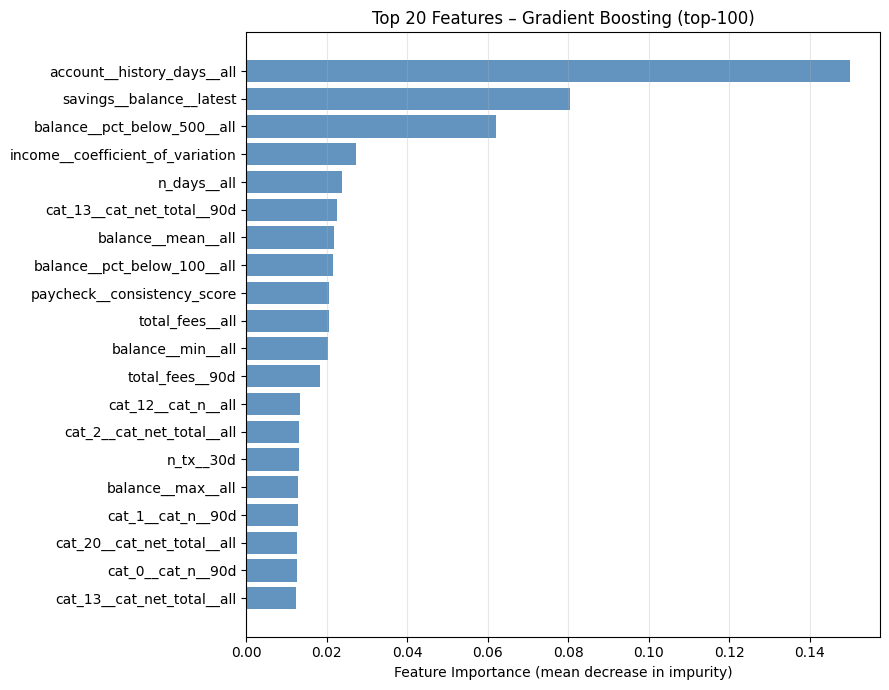

In [21]:
importance_df = pd.DataFrame({
    'feature':    available_features,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False)

print('Top 20 Features by Impurity Importance:')
print(importance_df.head(20).to_string(index=False))

top20 = importance_df.head(20)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(range(len(top20)), top20['importance'][::-1], color='steelblue', alpha=0.85)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'][::-1].tolist())
ax.set_xlabel('Feature Importance (mean decrease in impurity)')
ax.set_title(f'Top 20 Features – Gradient Boosting (top-{N_FEATURES})')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. ROC & Precision-Recall Curves

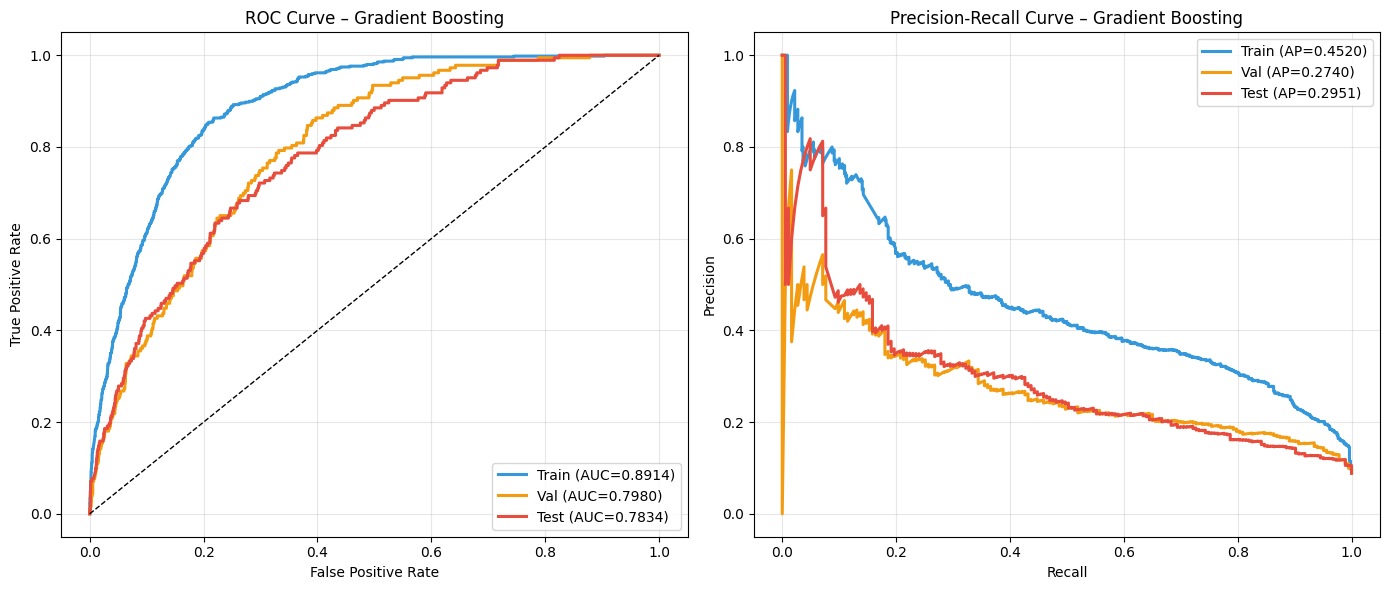

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colours = {'Train': '#3498db', 'Val': '#f39c12', 'Test': '#e74c3c'}

for preds, targets, name in [
    (train_preds, y_train, 'Train'),
    (val_preds,   y_val,   'Val'),
    (test_preds,  y_test,  'Test'),
]:
    # ROC
    fpr, tpr, _ = roc_curve(targets, preds)
    auc_v = roc_auc_score(targets, preds)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_v:.4f})',
                 color=colours[name], linewidth=2.2)

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(targets, preds)
    ap_v = average_precision_score(targets, preds)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap_v:.4f})',
                 color=colours[name], linewidth=2.2)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.0)
axes[0].set(title='ROC Curve – Gradient Boosting',
            xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].set(title='Precision-Recall Curve – Gradient Boosting',
            xlabel='Recall', ylabel='Precision')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()